In [15]:
# importing libraries
import pandas as pd # for reading files and handling dataset
import numpy as np # for mathematical operations
import matplotlib.pyplot as plt # for graphical visualization

In [16]:
# Loading dataset
df = pd.read_csv(r"C:\Users\rasika\Downloads\amazonreviews.tsv", sep = '\t')
df

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9995,pos,A revelation of life in small town America in ...
9996,pos,Great biography of a very interesting journali...
9997,neg,Interesting Subject; Poor Presentation: You'd ...
9998,neg,Don't buy: The box looked used and it is obvio...


In [17]:
# Dataset summary
df.info() # number of entries, number of columns and there data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [18]:
# checking fo missing values
df.isnull().sum()

label     0
review    0
dtype: int64

#### No missing values occur in dataset

In [19]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

#### No duplicates rows occur in dataset

### Label Encoding 
Positive - Encoded as 1

Negative - Encoded as 0

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['label'] = le.fit_transform(df['label'])
df['label'].head()

0    1
1    1
2    1
3    1
4    1
Name: label, dtype: int64

array([[<Axes: title={'center': 'label'}>]], dtype=object)

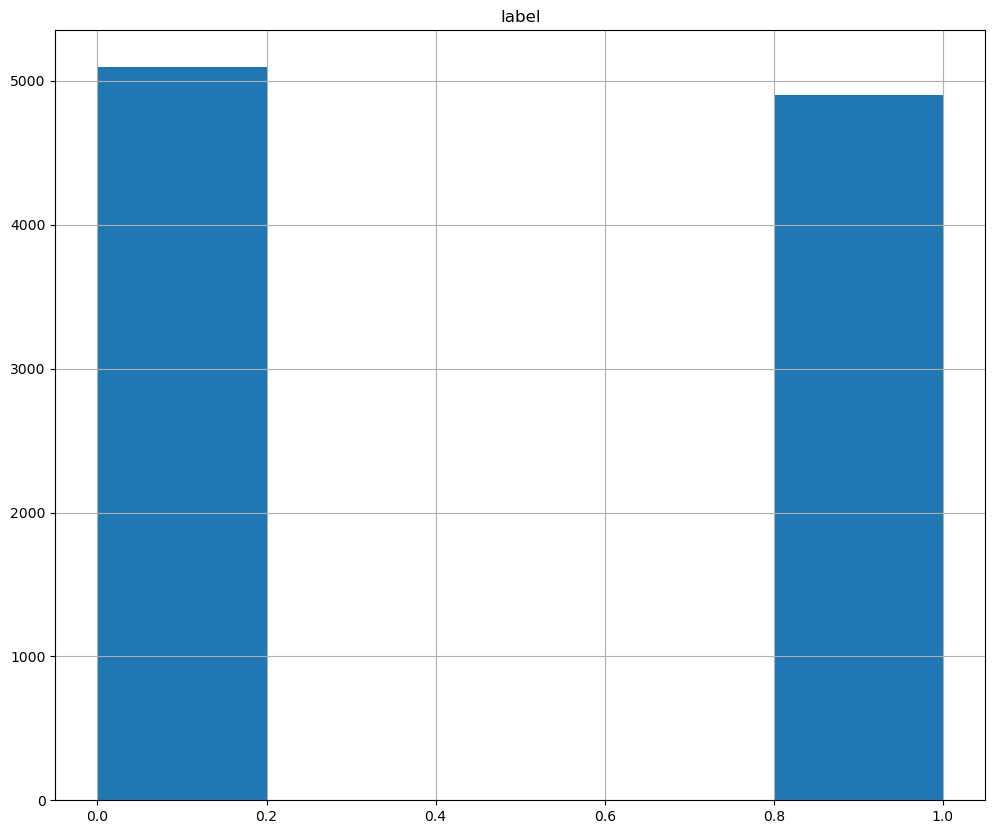

In [21]:
df.hist(bins = 5, figsize = (12, 10))

#### This visualizes that Negative revies are more than positive reviews

### Text Preprocessing

In [57]:
import nltk
nltk.download('stopwords') # provides list of common words
nltk.download('punkt_tab') # splits text into words properly
nltk.download('wordnet') #Used for lemmatization 
nltk.download('omw-1.4') # supports to understand word meaning, multilingual mapping

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rasika\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rasika\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rasika\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\rasika\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [35]:
from nltk.corpus import stopwords # Natural Language ToolKit for text preprocessing and NLP tasks from it importing stopword, removes word that add no meaning in text 
from nltk.tokenize import word_tokenize # split text by comma(,)
import re # Regular Expression to clean text by removing punctuations, numbers, urls, special characters
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ' , text)
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

In [36]:
# Applying cleaning 
df['clean_review'] = df['review'].apply(clean_text)
df[['review', 'clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even non gamer sound track beautiful p...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything reading lot revi...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing played game kn...


### Exploratory Analysis

In [39]:
!pip install wordcloud

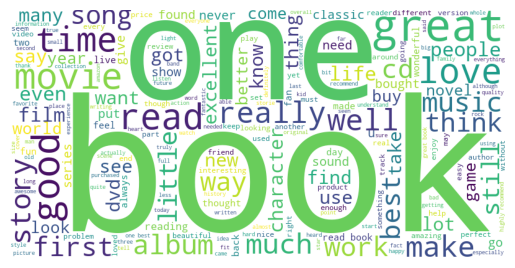

In [40]:
# Word Cloud for Positive reviews
from wordcloud import WordCloud # shows frequently occuring words

positive_reviews = " ".join(df[df['label']==1]['clean_review'])

wordcloud = WordCloud(width= 800, height = 400, background_color = 'white').generate(positive_reviews)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

##### In visualization words displayed in large font size are appeared most frequently in data and with small size are appeared very few times

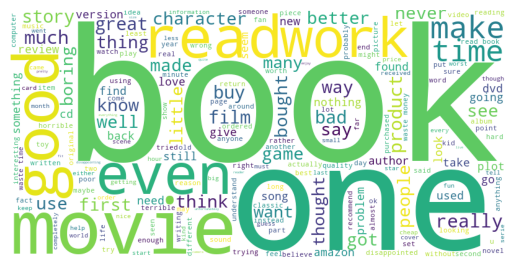

In [41]:
# Wordcloud forr negative reviews 
negative_reviews = " ".join(df[df['label'] == 0]['clean_review'])
wordcloud = WordCloud(width = 800, height = 400, background_color = 'white').generate(negative_reviews)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [45]:
# Feature Extraction using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer # convert text into numerical features
vectorizer = TfidfVectorizer(max_features = 5000)
X = vectorizer.fit_transform(df['clean_review'])
y = df['label']

In [46]:
# Train-Test Split. 80% data for training, 20% for testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size = 0.2, random_state = 42)

### Building Logistic Regression Model

In [49]:
# Logistics regression is one of the best baseline method for sentimnt analysis
# creating object model 
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr_model = lr.fit(X_train, y_train)

# making prediction on test data
y_pred = lr.predict(X_test)

### Model Evaluation

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Model Accuracy ', accuracy)
print('Precision Score ', precision)
print('Recall Score ', recall)
print('F1 Score ', f1)

Model Accuracy  0.8515
Precision Score  0.8490566037735849
Recall Score  0.8411214953271028
F1 Score  0.8450704225352113


#### Overall Interpretation
1. The dataset was successfully preprocessed by checking for missing values and duplicate records.
2. Text preprocessing included lowercasing, removal of special characters, tokenization, and stopword removal using NLTK.These steps reduced noise and improved text quality.
3. TF-IDF vectorization was then applied to convert textual reviews into numerical features, enabling machine learning algorithms to process the data effectively. The use of a maximum of 5000 features ensured a balance between information retention and computational efficiency.
4. A Logistic Regression classifier was trained using an 80-20 train-test split. Logistic Regression is a strong baseline model for sentiment analysis because it performs well on sparse TF-IDF features.
5. Model performance was evaluated using Accuracy, Precision, Recall, and F1-score. These metrics collectively provide a comprehensive understanding of classification performance and robustness.
6. Word Cloud visualizations revealed the most frequently occurring terms in both positive and negative reviews.
7. Positive reviews highlighted words associated with customer satisfaction and product quality, while negative reviews exposed recurring complaints and dissatisfaction factors.
8. Model performed well with 85% accuracy well classified positive and negative sentiments over reviews